---
## SECTION 1 — Library Imports

In [ ]:
import numpy as np
import pandas as pd
import warnings
import os
import re
import string
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# NLP / Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

#Train / Test Split
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Classifiers
from sklearn.naive_bayes      import GaussianNB
from sklearn.linear_model     import LogisticRegression
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.svm              import SVC
from sklearn.neural_network   import MLPClassifier
from sklearn.ensemble         import RandomForestClassifier, VotingClassifier
from sklearn.tree             import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)

print("All libraries loaded successfully.")
print(f"   numpy  : {np.__version__}")
print(f"   pandas : {pd.__version__}")
import sklearn; print(f"   sklearn: {sklearn.__version__}")

All libraries loaded successfully.
   numpy  : 2.0.2
   pandas : 2.2.2
   sklearn: 1.6.1


---
## SECTION 2 — Data Loading & Merging



In [ ]:
 from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/CSE477_Project'

FILES = {
    'Psy'       : 'Youtube01-Psy.csv',
    'KatyPerry' : 'Youtube02-KatyPerry.csv',
    'LMFAO'     : 'Youtube03-LMFAO.csv',
    'Eminem'    : 'Youtube04-Eminem.csv',
    'Shakira'   : 'Youtube05-Shakira.csv'
}

# Load and label each file with its video source
dfs = []
for artist, filename in FILES.items():
    path = os.path.join(BASE_PATH, filename)
    tmp  = pd.read_csv(path, encoding='latin-1')
    tmp['VIDEO'] = artist
    dfs.append(tmp)
    print(f"  Loaded {filename:30s} → {len(tmp):4d} rows")

#  Merge all 5 files
df = pd.concat(dfs, ignore_index=True)

print(f"\n Combined dataset shape : {df.shape}")
print(f"   Columns               : {df.columns.tolist()}")
print(f"\nFirst 10 rows:")
df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Loaded Youtube01-Psy.csv              →  350 rows
  Loaded Youtube02-KatyPerry.csv        →  350 rows
  Loaded Youtube03-LMFAO.csv            →  438 rows
  Loaded Youtube04-Eminem.csv           →  448 rows
  Loaded Youtube05-Shakira.csv          →  370 rows

 Combined dataset shape : (1956, 6)
   Columns               : ['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS', 'VIDEO']

First 10 rows:


,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS,VIDEO
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1,Psy
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1,Psy
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1,Psy
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^...,1,Psy
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .ï»¿,1,Psy
5,LZQPQhLyRh9-wNRtlZDM90f1k0BrdVdJyN_YsaSwfxc,Jason Haddad,2013-11-26T02:55:11,"Hey, check out my new website!! This site is a...",1,Psy
6,z13lfzdo5vmdi1cm123te5uz2mqig1brz04,ferleck ferles,2013-11-27T21:39:24,Subscribe to my channel ï»¿,1,Psy
7,z122wfnzgt30fhubn04cdn3xfx2mxzngsl40k,Bob Kanowski,2013-11-28T12:33:27,i turned it on mute as soon is i came on i jus...,0,Psy
8,z13ttt1jcraqexk2o234ghbgzxymz1zzi04,Cony,2013-11-28T16:01:47,You should check my channel for Funny VIDEOS!!ï»¿,1,Psy
9,z12avveb4xqiirsix04chxviiljryduwxg0,BeBe Burkey,2013-11-28T16:30:13,and u should.d check my channel and tell me wh...,1,Psy


In [ ]:
# Basic integrity checks
print("Shape ")
print(f"  Total rows   : {len(df)}")
print(f"  Total columns: {df.shape[1]}")

print("\n Missing values ")
print(df.isnull().sum())

print("\n CLASS distribution ")
vc = df['CLASS'].value_counts()
print(f"  Spam (1) : {vc[1]} ({vc[1]/len(df)*100:.1f}%)")
print(f"  Ham  (0) : {vc[0]} ({vc[0]/len(df)*100:.1f}%)")

print("\n Per-video class distribution ")
print(df.groupby(['VIDEO','CLASS']).size().unstack(fill_value=0))

Shape 
  Total rows   : 1956
  Total columns: 6

 Missing values 
COMMENT_ID      0
AUTHOR          0
DATE          245
CONTENT         0
CLASS           0
VIDEO           0
dtype: int64

 CLASS distribution 
  Spam (1) : 1005 (51.4%)
  Ham  (0) : 951 (48.6%)

 Per-video class distribution 
CLASS        0    1
VIDEO              
Eminem     203  245
KatyPerry  175  175
LMFAO      202  236
Psy        175  175
Shakira    196  174


In [ ]:
# Drop duplicates and null CONTENT rows
before = len(df)
df.drop_duplicates(subset=['COMMENT_ID'], inplace=True)
df.dropna(subset=['CONTENT'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows before dedup: {before}  →  after: {len(df)}  (removed {before - len(df)})")

Rows before dedup: 1956  →  after: 1953  (removed 3)


---
## SECTION 3 — Exploratory Data Analysis (EDA)

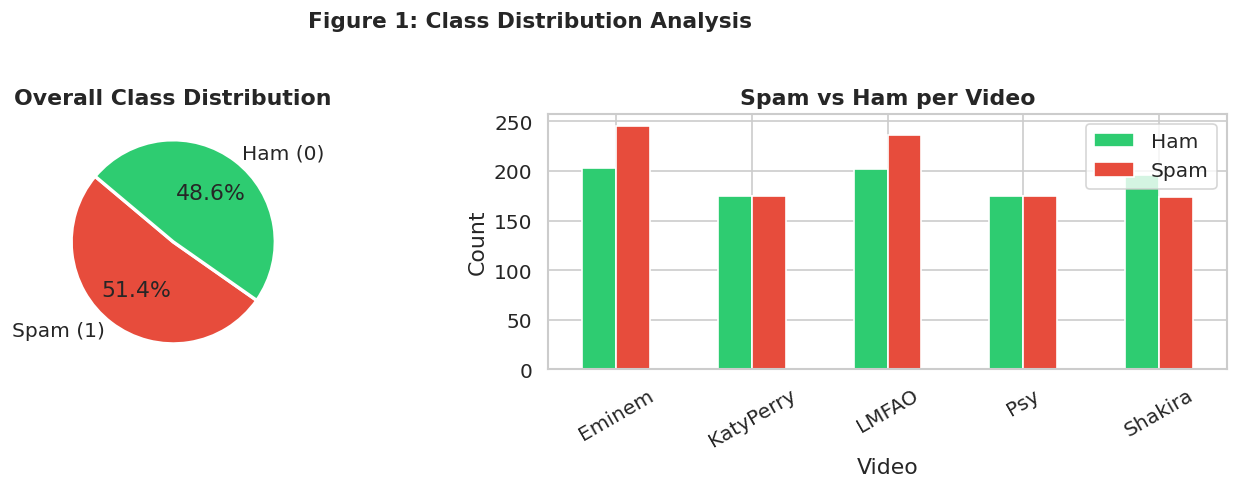

Saved: fig1_class_distribution.png


In [ ]:
# Class Balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall pie
vc = df['CLASS'].value_counts()
axes[0].pie(
    vc.values,
    labels=['Spam (1)', 'Ham (0)'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Class Distribution', fontweight='bold')

# Per-video bar
video_dist = df.groupby(['VIDEO','CLASS']).size().unstack(fill_value=0)
video_dist.columns = ['Ham', 'Spam']
video_dist.plot(
    kind='bar', ax=axes[1],
    color=['#2ecc71','#e74c3c'], edgecolor='white'
)
axes[1].set_title('Spam vs Ham per Video', fontweight='bold')
axes[1].set_xlabel('Video')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Figure 1: Class Distribution Analysis', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: fig1_class_distribution.png")

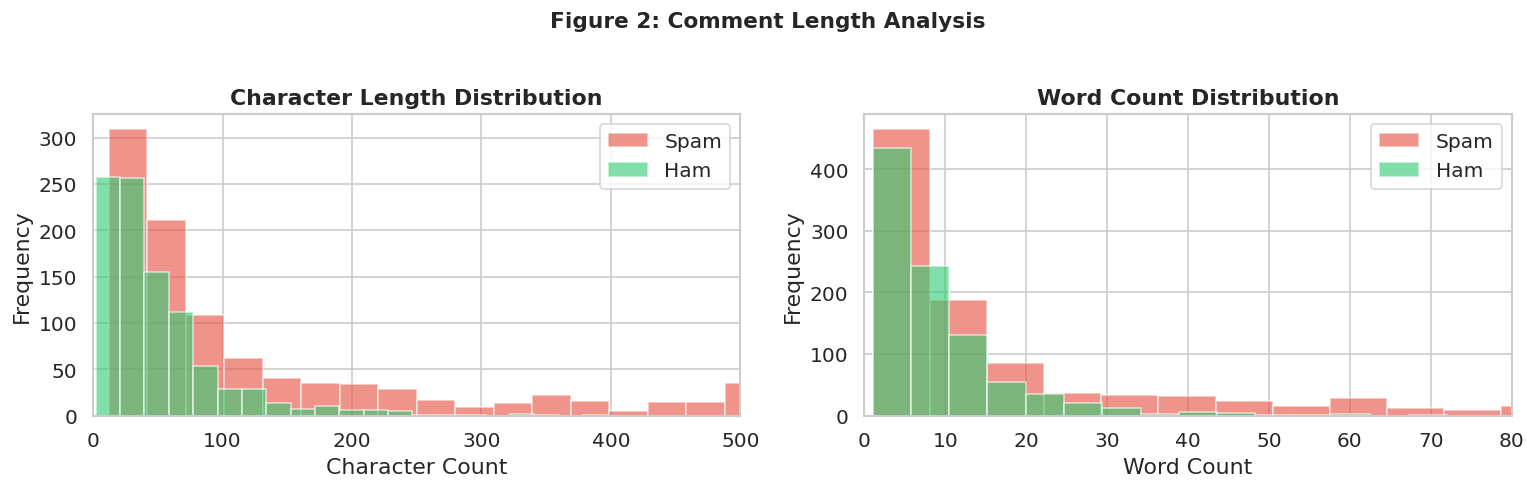


── Average character length ──
CLASS
Ham      52.6
Spam    140.8
Name: CHAR_LEN, dtype: float64

── Average word count ──
CLASS
Ham      9.1
Spam    21.8
Name: WORD_COUNT, dtype: float64


In [ ]:
# 3.2  Comment Length Analysis
df['CHAR_LEN']  = df['CONTENT'].str.len()
df['WORD_COUNT']= df['CONTENT'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, name in [(1,'#e74c3c','Spam'), (0,'#2ecc71','Ham')]:
    subset = df[df['CLASS'] == label]['CHAR_LEN']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')

axes[0].set_title('Character Length Distribution', fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 500)

for label, color, name in [(1,'#e74c3c','Spam'), (0,'#2ecc71','Ham')]:
    subset = df[df['CLASS'] == label]['WORD_COUNT']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=name, edgecolor='white')

axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 80)

plt.suptitle('Figure 2: Comment Length Analysis', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_comment_length.png', bbox_inches='tight')
plt.show()

print("\n── Average character length ──")
print(df.groupby('CLASS')['CHAR_LEN'].mean().rename({0:'Ham', 1:'Spam'}).round(1))
print("\n── Average word count ──")
print(df.groupby('CLASS')['WORD_COUNT'].mean().rename({0:'Ham', 1:'Spam'}).round(1))

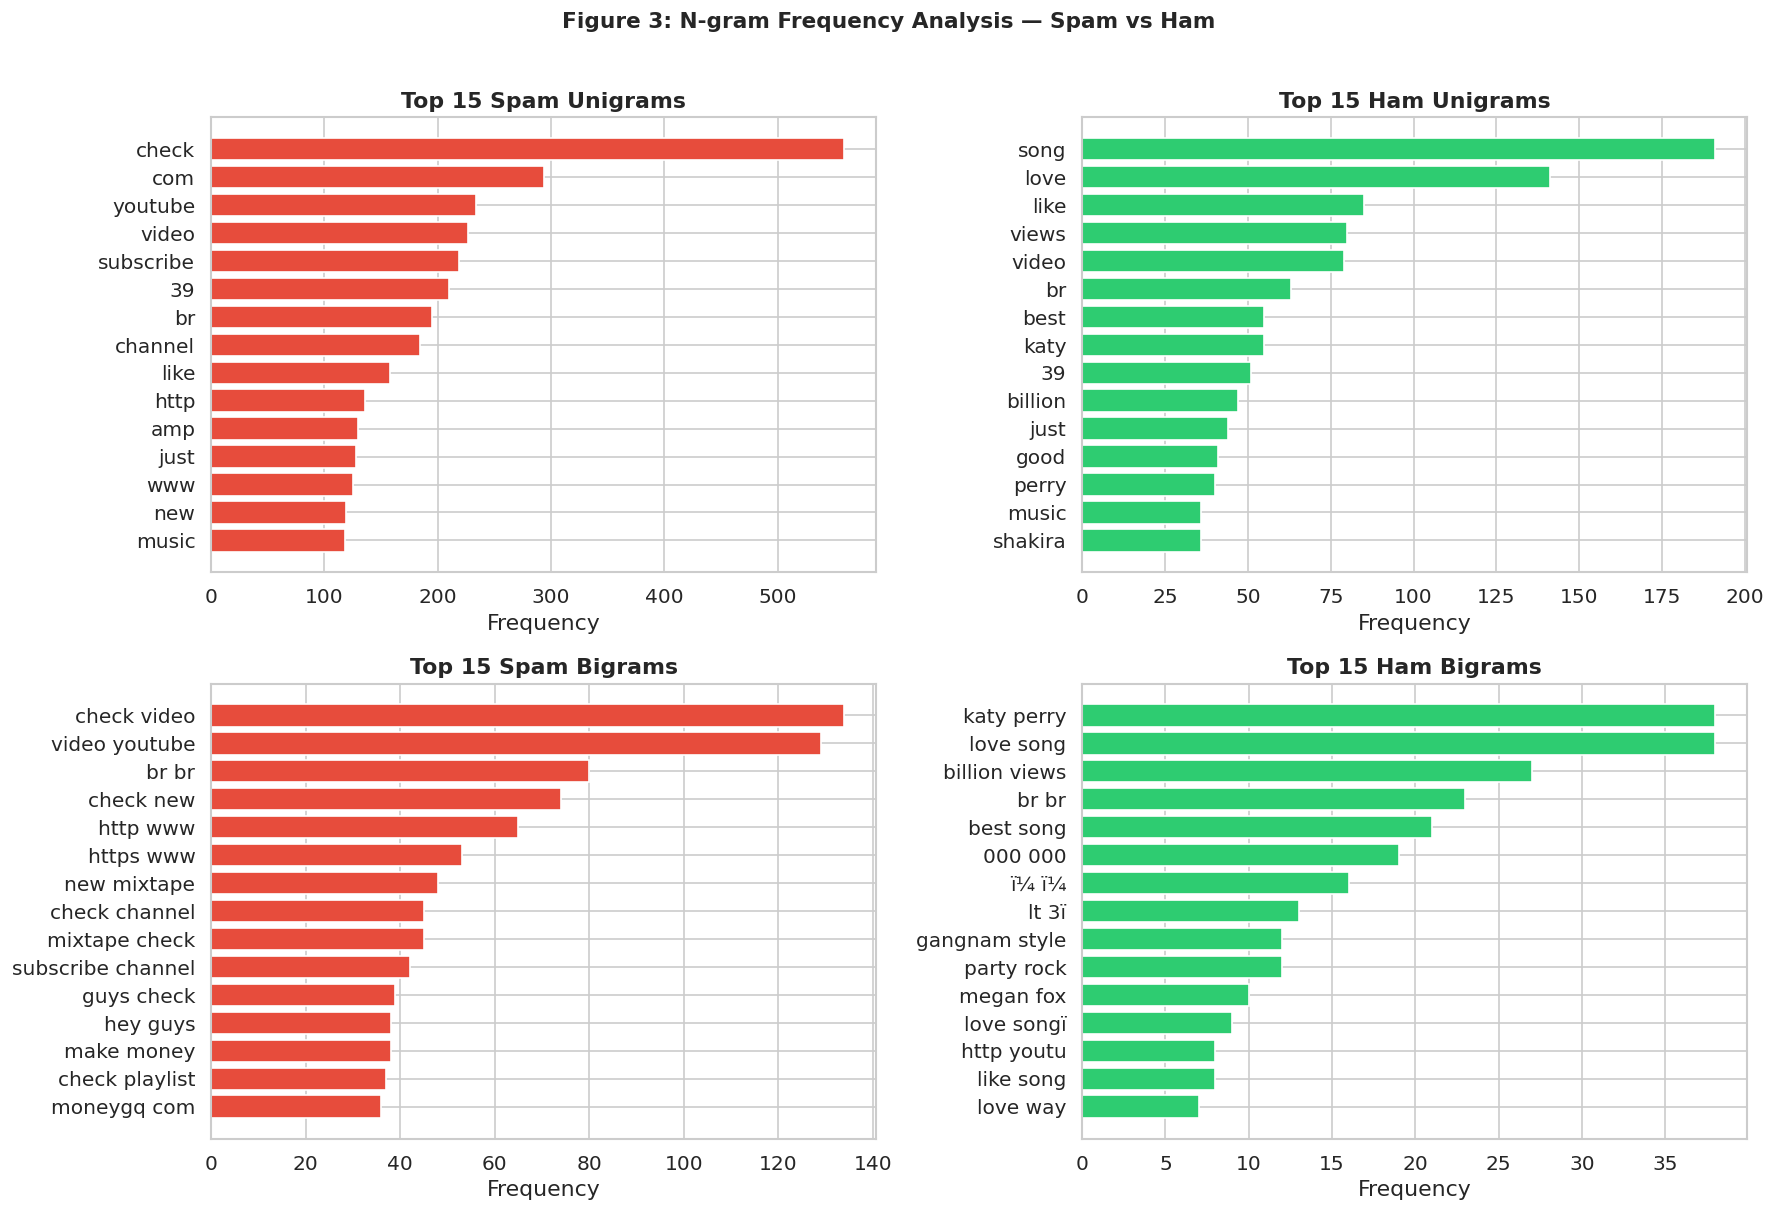

In [ ]:
# 3.3  Top N-gram Frequency: Spam vs Ham
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(corpus, n=1, top_k=15):
    """Return top_k most frequent n-grams from corpus."""
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english',
                          max_features=5000).fit(corpus)
    bag = vec.transform(corpus)
    freq = zip(vec.get_feature_names_out(), np.asarray(bag.sum(axis=0)).ravel())
    return sorted(freq, key=lambda x: x[1], reverse=True)[:top_k]

spam_text = df[df['CLASS'] == 1]['CONTENT'].astype(str)
ham_text  = df[df['CLASS'] == 0]['CONTENT'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for row_idx, n_val, n_name in [(0, 1, 'Unigrams'), (1, 2, 'Bigrams')]:
    spam_ng = top_ngrams(spam_text, n=n_val)
    ham_ng  = top_ngrams(ham_text,  n=n_val)

    # Spam
    terms, freqs = zip(*spam_ng)
    axes[row_idx][0].barh(list(reversed(terms)), list(reversed(freqs)),
                          color='#e74c3c', edgecolor='white')
    axes[row_idx][0].set_title(f'Top 15 Spam {n_name}', fontweight='bold')
    axes[row_idx][0].set_xlabel('Frequency')

    # Ham
    terms, freqs = zip(*ham_ng)
    axes[row_idx][1].barh(list(reversed(terms)), list(reversed(freqs)),
                          color='#2ecc71', edgecolor='white')
    axes[row_idx][1].set_title(f'Top 15 Ham {n_name}', fontweight='bold')
    axes[row_idx][1].set_xlabel('Frequency')

plt.suptitle('Figure 3: N-gram Frequency Analysis — Spam vs Ham', fontsize=13,
             y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_ngram_frequency.png', bbox_inches='tight')
plt.show()

---
## SECTION 4 — Text Preprocessing



In [ ]:
def preprocess_text(text):
    """
    Clean a single YouTube comment string.
    Steps:
      1. Lowercase
      2. Remove URLs
      3. Remove HTML tags
      4. Remove punctuation & special characters
      5. Remove digits
      6. Strip extra whitespace
    """
    if not isinstance(text, str):
        return ''
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 3. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 4. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
df['CONTENT_CLEAN'] = df['CONTENT'].apply(preprocess_text)

# Show before / after
print("── Before / After Preprocessing (3 examples) ──────────────")
for i in range(3):
    print(f"\n[{i+1}] RAW   : {df['CONTENT'].iloc[i][:120]}")
    print(f"    CLEAN : {df['CONTENT_CLEAN'].iloc[i][:120]}")

# Check for empty strings after cleaning
empty = (df['CONTENT_CLEAN'].str.strip() == '').sum()
print(f"\nRows with empty CONTENT after cleaning: {empty}")
if empty > 0:
    df = df[df['CONTENT_CLEAN'].str.strip() != ''].reset_index(drop=True)
    print(f"Removed empty rows. New size: {len(df)}")

── Before / After Preprocessing (3 examples) ──────────────

[1] RAW   : Huh, anyway check out this you[tube] channel: kobyoshi02
    CLEAN : huh anyway check out this youtube channel kobyoshi

[2] RAW   : Hey guys check out my new channel and our first vid THIS IS US THE  MONKEYS!!! I'm the monkey in the white shirt,please 
    CLEAN : hey guys check out my new channel and our first vid this is us the monkeys im the monkey in the white shirtplease leave 

[3] RAW   : just for test I have to say murdev.com
    CLEAN : just for test i have to say murdevcom

Rows with empty CONTENT after cleaning: 63
Removed empty rows. New size: 1893


---
## SECTION 5 — Feature Extraction(TF-IDF Vectorization)



In [ ]:
# ── Labels ────────────────────────────────────────────────────────────────────
X_text = df['CONTENT_CLEAN']
y      = df['CLASS'].values

print(f"Total samples  : {len(X_text)}")
print(f"Spam (1) count : {y.sum()}")
print(f"Ham  (0) count : {(y == 0).sum()}")

# ── TF-IDF Unigram (Paper replication) ───────────────────────────────────────
tfidf_uni = TfidfVectorizer(
    ngram_range=(1, 1),
    max_features=5000,
    sublinear_tf=True,        # apply log(1+tf) — common practice
    stop_words='english'
)
X_uni = tfidf_uni.fit_transform(X_text)
print(f"\n[Unigram TF-IDF] Matrix shape : {X_uni.shape}")
print(f"  → {X_uni.shape[0]} comments × {X_uni.shape[1]} features")

# ── TF-IDF Bigram (Our extension) ─────────────────────────────────────────────
tfidf_bi = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    sublinear_tf=True,
    stop_words='english'
)
X_bi = tfidf_bi.fit_transform(X_text)
print(f"\n[Bigram TF-IDF]  Matrix shape : {X_bi.shape}")
print(f"  → {X_bi.shape[0]} comments × {X_bi.shape[1]} features")

# ── Top 10 features by mean TF-IDF score ─────────────────────────────────────
feature_names = tfidf_uni.get_feature_names_out()
mean_tfidf    = np.asarray(X_uni.mean(axis=0)).ravel()
top10_idx     = mean_tfidf.argsort()[-10:][::-1]
print("\nTop 10 unigram features by mean TF-IDF score:")
for rank, idx in enumerate(top10_idx, 1):
    print(f"  {rank:2d}. {feature_names[idx]:20s}  {mean_tfidf[idx]:.5f}")

Total samples  : 1893
Spam (1) count : 952
Ham  (0) count : 941

[Unigram TF-IDF] Matrix shape : (1893, 3564)
  → 1893 comments × 3564 features

[Bigram TF-IDF]  Matrix shape : (1893, 5000)
  → 1893 comments × 5000 features

Top 10 unigram features by mean TF-IDF score:
   1. check                 0.06430
   2. video                 0.05469
   3. youtube               0.05268
   4. song                  0.04421
   5. love                  0.04032
   6. subscribe             0.03571
   7. like                  0.03269
   8. channel               0.02692
   9. best                  0.01815
  10. views                 0.01723


---
## SECTION 6 — Train / Test Split

In [ ]:
 # Unigram split
X_train_uni, X_test_uni, y_train, y_test = train_test_split(
    X_uni, y, test_size=0.2, random_state=SEED, stratify=y
)

# Bigram split
X_train_bi, X_test_bi, _, _ = train_test_split(
    X_bi, y, test_size=0.2, random_state=SEED, stratify=y
)

print("── Train / Test Split (80/20 stratified) ──────────────────")
print(f"  Training set size : {X_train_uni.shape[0]} comments")
print(f"  Test set size     : {X_test_uni.shape[0]}  comments")
print(f"\n  Training — Spam: {y_train.sum()}  Ham: {(y_train==0).sum()}")
print(f"  Test     — Spam: {y_test.sum()}   Ham: {(y_test==0).sum()}")

# GaussianNB requires dense arrays
X_train_uni_dense = X_train_uni.toarray()
X_test_uni_dense  = X_test_uni.toarray()
X_train_bi_dense  = X_train_bi.toarray()
X_test_bi_dense   = X_test_bi.toarray()

print("\n Splits ready. Dense arrays prepared for GaussianNB.")

── Train / Test Split (80/20 stratified) ──────────────────
  Training set size : 1514 comments
  Test set size     : 379  comments

  Training — Spam: 761  Ham: 753
  Test     — Spam: 191   Ham: 188

 Splits ready. Dense arrays prepared for GaussianNB.


---
## SECTION 7 — Model Training (8 Classifiers — Paper Replication)

Replicating all 8 classifiers from Xiao & Liang (2024):
1. Gaussian Naive Bayes  
2. Logistic Regression  
3. K-Nearest Neighbors  
4. Support Vector Machine  
5. Multi-Layer Perceptron  
6. Random Forest  
7. Decision Tree  
8. Voting Classifier (ensemble of 1–7)

In [ ]:
#  Define all 7 base classifiers
base_classifiers = [
    ('Gaussian NB',        GaussianNB()),
    ('Logistic Regression',LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)),
    ('KNN (k=5)',          KNeighborsClassifier(n_neighbors=5)),
    ('SVM (RBF)',          SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED)),
    ('MLP',                MLPClassifier(hidden_layer_sizes=(100,), max_iter=500,
                                          random_state=SEED)),
    ('Random Forest',      RandomForestClassifier(n_estimators=100, max_depth=None,
                                                    random_state=SEED)),
    ('Decision Tree',      DecisionTreeClassifier(max_depth=None, random_state=SEED)),
]

# ── Voting Classifier — soft voting over all 7 base models ───────────────────

voting_clf = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)),
        ('svm', SVC(kernel='rbf', probability=True, random_state=SEED)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=SEED)),
        ('dt',  DecisionTreeClassifier(random_state=SEED)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=SEED))
    ],
    voting='soft'
)

all_classifiers = base_classifiers + [('Voting Classifier', voting_clf)]
print(f" Defined {len(all_classifiers)} classifiers (7 base + 1 voting ensemble)")
for name, _ in all_classifiers:
    print(f"   • {name}")

 Defined 8 classifiers (7 base + 1 voting ensemble)
   • Gaussian NB
   • Logistic Regression
   • KNN (k=5)
   • SVM (RBF)
   • MLP
   • Random Forest
   • Decision Tree
   • Voting Classifier


In [ ]:
#  Training loop — Unigram TF-IDF (Paper Replication)
DENSE_MODELS = {'Gaussian NB'}

trained_models = {}   # store fitted models for reuse in extension

print("Training all 8 classifiers on Unigram TF-IDF features...")
print("─" * 55)

for name, clf in all_classifiers:
    X_tr = X_train_uni_dense if name in DENSE_MODELS else X_train_uni
    clf.fit(X_tr, y_train)
    trained_models[name] = clf
    print(f"   Trained : {name}")

print("\n All models trained successfully on Unigram TF-IDF.")

Training all 8 classifiers on Unigram TF-IDF features...
───────────────────────────────────────────────────────
   Trained : Gaussian NB
   Trained : Logistic Regression
   Trained : KNN (k=5)
   Trained : SVM (RBF)
   Trained : MLP
   Trained : Random Forest
   Trained : Decision Tree
   Trained : Voting Classifier

 All models trained successfully on Unigram TF-IDF.


---
## SECTION 8 — Evaluation: Paper Metrics (Precision + AUC-ROC)


In [ ]:
def evaluate_paper_metrics(name, clf, X_test, X_test_dense, y_test):
    """Compute Accuracy, Precision, AUC-ROC — paper's reported metrics."""
    X_ev = X_test_dense if name in DENSE_MODELS else X_test
    y_pred = clf.predict(X_ev)
    y_prob = clf.predict_proba(X_ev)[:, 1]

    return {
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, zero_division=0),
        'AUC-ROC'   : roc_auc_score(y_test, y_prob)
    }

#  Collect paper metrics for all 8 models
paper_results = []
for name, clf in all_classifiers:
    row = evaluate_paper_metrics(
        name, clf, X_test_uni, X_test_uni_dense, y_test
    )
    paper_results.append(row)

df_paper = pd.DataFrame(paper_results).sort_values('AUC-ROC', ascending=False)
df_paper = df_paper.reset_index(drop=True)

# Round for display
display_cols = ['Accuracy','Precision','AUC-ROC']
df_paper_disp = df_paper.copy()
df_paper_disp[display_cols] = df_paper_disp[display_cols].round(4)

print("═" * 60)
print("TABLE 1: Paper Replication Results (Unigram TF-IDF)")
print("═" * 60)
print(df_paper_disp.to_string(index=False))
print("═" * 60)
best_row = df_paper.iloc[0]
print(f"\n★ Best model : {best_row['Model']}")
print(f"  AUC-ROC   : {best_row['AUC-ROC']:.4f}")
print(f"  Precision  : {best_row['Precision']:.4f}")
print(f"  Accuracy   : {best_row['Accuracy']:.4f}")

════════════════════════════════════════════════════════════
TABLE 1: Paper Replication Results (Unigram TF-IDF)
════════════════════════════════════════════════════════════
              Model  Accuracy  Precision  AUC-ROC
  Voting Classifier    0.9446     0.9620   0.9821
      Random Forest    0.9367     0.9665   0.9819
Logistic Regression    0.9367     0.9665   0.9732
          SVM (RBF)    0.9340     0.9663   0.9731
                MLP    0.9077     0.9432   0.9546
      Decision Tree    0.9208     0.9259   0.9338
          KNN (k=5)    0.6675     0.9851   0.8725
        Gaussian NB    0.7361     0.8095   0.7371
════════════════════════════════════════════════════════════

★ Best model : Voting Classifier
  AUC-ROC   : 0.9821
  Precision  : 0.9620
  Accuracy   : 0.9446


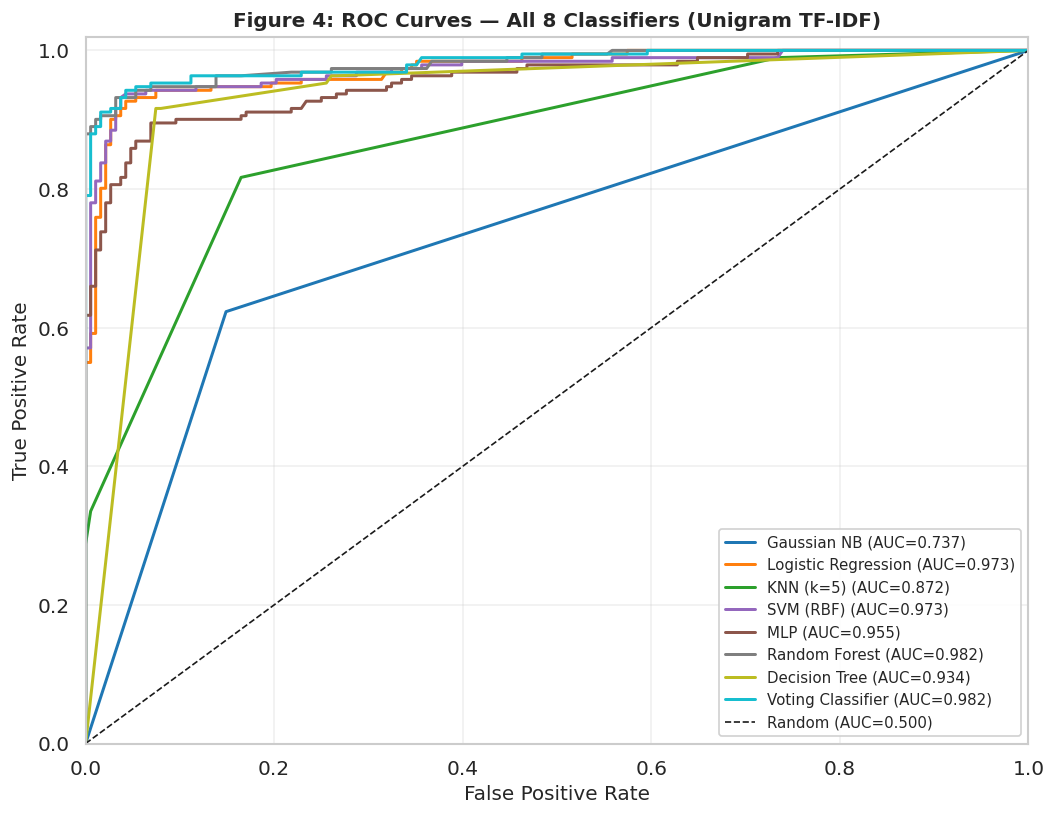

Saved: fig4_roc_curves.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# ── Figure 4: ROC Curves — all 8 models on one plot (paper Figure 3 style) ──
fig, ax = plt.subplots(figsize=(9, 7))

# Generate distinct colors for each of the 8 classifiers
colors = plt.cm.tab10(np.linspace(0, 1, len(all_classifiers)))

# Loop through every classifier and plot its curve on the SAME axis (ax)
for (name, clf), color in zip(all_classifiers, colors):
    # Check if the model requires dense data (like GaussianNB)
    X_ev   = X_test_uni_dense if name in DENSE_MODELS else X_test_uni

    # Get prediction probabilities
    y_prob = clf.predict_proba(X_ev)[:, 1]

    # Calculate False Positive Rate, True Positive Rate, and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    # Plot the curve on the single graph
    ax.plot(fpr, tpr, color=color, lw=1.8, label=f"{name} (AUC={auc:.3f})")

# Add the random baseline dashed line
ax.plot([0,1], [0,1], 'k--', lw=1, label='Random (AUC=0.500)')

# Graph formatting
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 4: ROC Curves — All 8 Classifiers (Unigram TF-IDF)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_xlim([0, 1.0])
ax.set_ylim([0, 1.02])
plt.grid(alpha=0.3) # Added a light grid for better readability

# Save and show
plt.tight_layout()
plt.savefig('fig4_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: fig4_roc_curves.png")

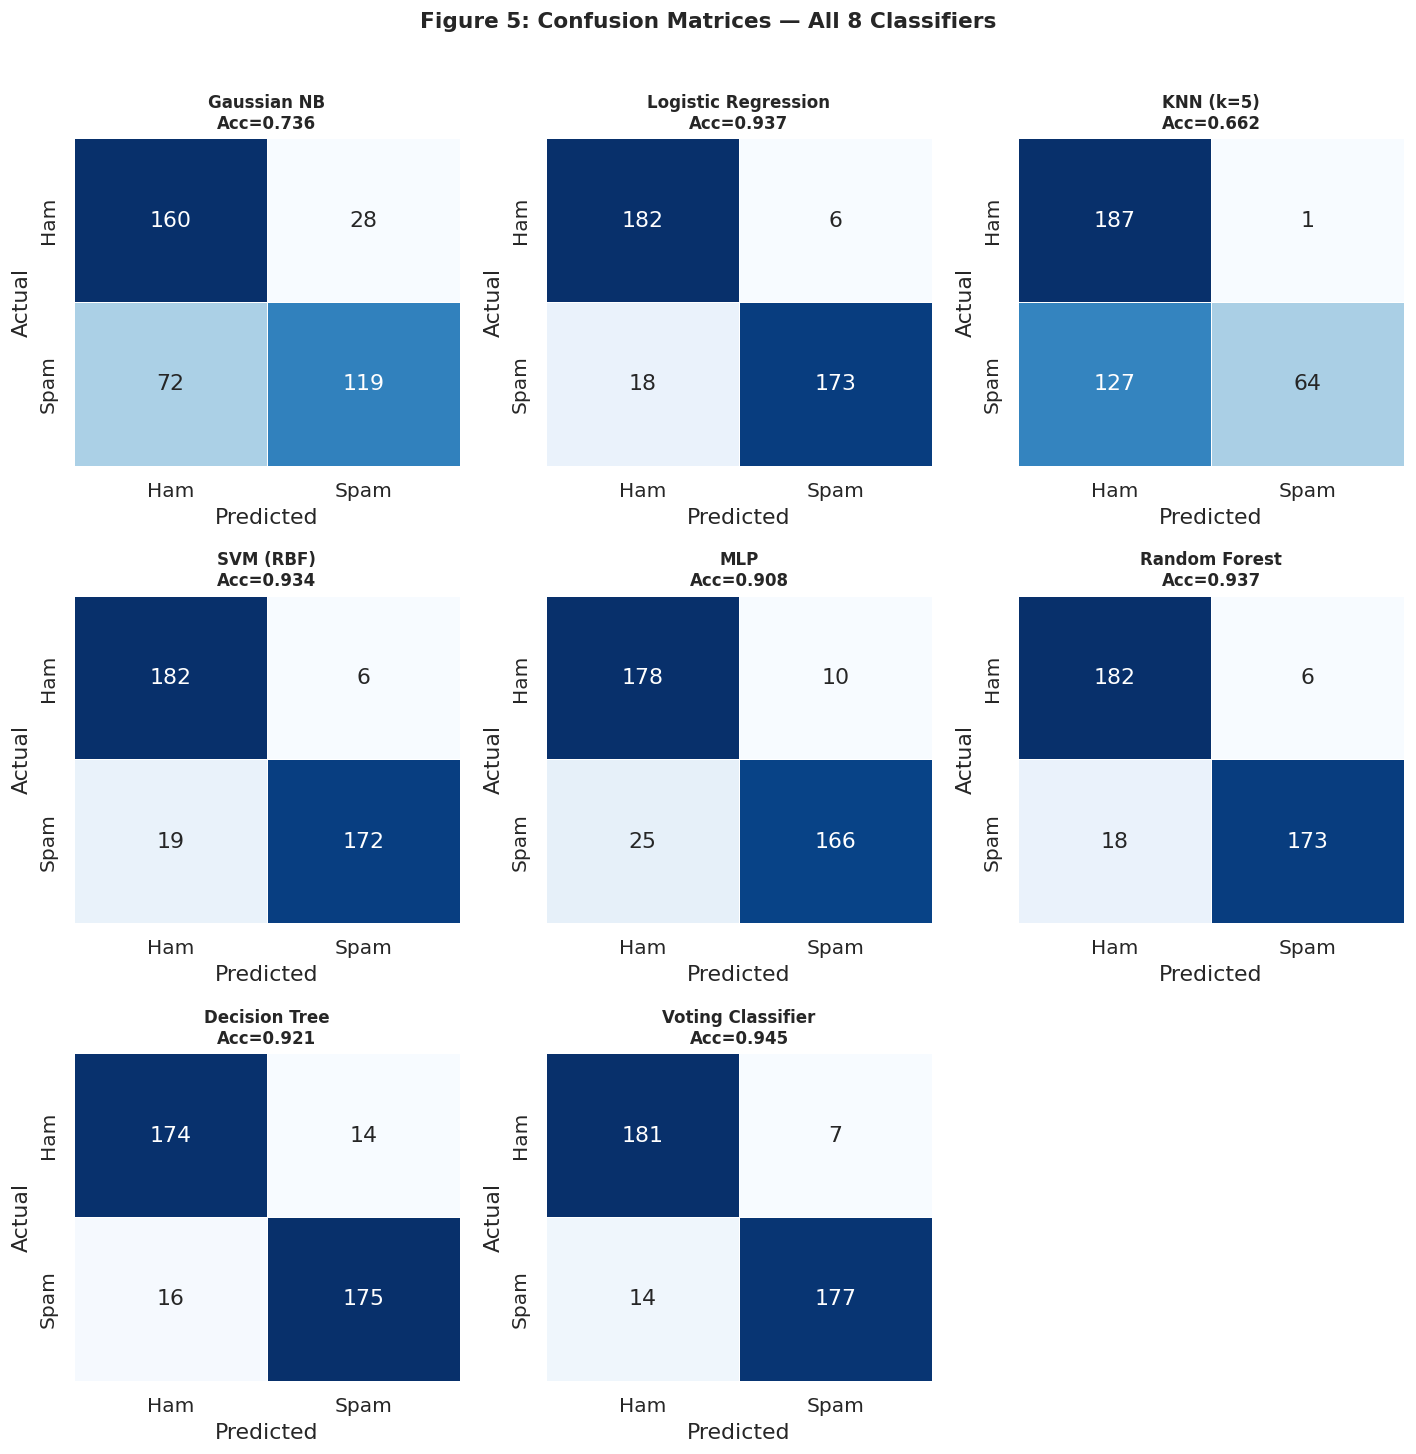

Saved: fig5_confusion_matrices.png


In [ ]:
#  Confusion Matrices  of all 8 models
n_models = len(all_classifiers)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 4))
axes = axes.ravel()

for idx, (name, clf) in enumerate(all_classifiers):
    X_ev   = X_test_uni_dense if name in DENSE_MODELS else X_test_uni
    y_pred = clf.predict(X_ev)
    cm     = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm, annot=True, fmt='d', ax=axes[idx],
        cmap='Blues', linewidths=0.5,
        xticklabels=['Ham','Spam'],
        yticklabels=['Ham','Spam'],
        cbar=False
    )
    acc = accuracy_score(y_test, y_pred)
    axes[idx].set_title(f"{name}\nAcc={acc:.3f}", fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Figure 5: Confusion Matrices — All 8 Classifiers',
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Saved: fig5_confusion_matrices.png")

---
## SECTION 9 — OUR EXTENSION



In [ ]:

def evaluate_full_metrics(name, clf, X_test, X_test_dense, y_test, label='Unigram'):
    """Extended metrics: Accuracy, Precision, Recall, Macro F1, AUC-ROC."""
    X_ev   = X_test_dense if name in DENSE_MODELS else X_test
    y_pred = clf.predict(X_ev)
    y_prob = clf.predict_proba(X_ev)[:, 1]

    return {
        'Model'         : name,
        'N-gram'        : label,
        'Accuracy'      : accuracy_score(y_test, y_pred),
        'Precision'     : precision_score(y_test, y_pred, zero_division=0),
        'Recall (Spam)' : recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        'Recall (Ham)'  : recall_score(y_test, y_pred, pos_label=0, zero_division=0),
        'Macro F1'      : f1_score(y_test, y_pred, average='macro', zero_division=0),
        'AUC-ROC'       : roc_auc_score(y_test, y_prob)
    }

# ── Part A: Unigram extended metrics (using already-trained models) ───────────
ext_uni_results = []
for name, clf in all_classifiers:
    row = evaluate_full_metrics(
        name, clf, X_test_uni, X_test_uni_dense, y_test, label='Unigram (1,1)'
    )
    ext_uni_results.append(row)

print(" Unigram extended metrics computed.")

#  Part B: Retrain all models on Bigram TF-IDF and evaluate
print("\nTraining all 8 classifiers on Bigram TF-IDF features...")
print("─" * 55)

ext_bi_results = []
for name, clf_def in all_classifiers:
    # Re-instantiate a fresh model to avoid data leakage
    import copy
    clf_bi = copy.deepcopy(dict(all_classifiers)[name])
    X_tr = X_train_bi_dense if name in DENSE_MODELS else X_train_bi
    clf_bi.fit(X_tr, y_train)
    print(f"   Trained (bigram): {name}")

    row = evaluate_full_metrics(
        name, clf_bi, X_test_bi, X_test_bi_dense, y_test, label='Bigram (1,2)'
    )
    ext_bi_results.append(row)

print("\n All bigram models trained and evaluated.")

 Unigram extended metrics computed.

Training all 8 classifiers on Bigram TF-IDF features...
───────────────────────────────────────────────────────
   Trained (bigram): Gaussian NB
   Trained (bigram): Logistic Regression
   Trained (bigram): KNN (k=5)
   Trained (bigram): SVM (RBF)
   Trained (bigram): MLP
   Trained (bigram): Random Forest
   Trained (bigram): Decision Tree
   Trained (bigram): Voting Classifier

 All bigram models trained and evaluated.


In [ ]:
#  Combine and display Extension Results Table
df_ext = pd.DataFrame(ext_uni_results + ext_bi_results)
df_ext = df_ext.sort_values(['N-gram','Macro F1'], ascending=[True, False])
df_ext = df_ext.reset_index(drop=True)

metric_cols = ['Accuracy','Precision','Recall (Spam)','Recall (Ham)','Macro F1','AUC-ROC']
df_ext_disp = df_ext.copy()
df_ext_disp[metric_cols] = df_ext_disp[metric_cols].round(4)

print("═" * 90)
print("TABLE 2: OUR EXTENSION — Full Metrics (Unigram vs Bigram TF-IDF)")
print("═" * 90)
print(df_ext_disp.to_string(index=False))
print("═" * 90)

══════════════════════════════════════════════════════════════════════════════════════════
TABLE 2: OUR EXTENSION — Full Metrics (Unigram vs Bigram TF-IDF)
══════════════════════════════════════════════════════════════════════════════════════════
              Model        N-gram  Accuracy  Precision  Recall (Spam)  Recall (Ham)  Macro F1  AUC-ROC
  Voting Classifier  Bigram (1,2)    0.9472     0.9672         0.9267        0.9681    0.9472   0.9776
          SVM (RBF)  Bigram (1,2)    0.9393     0.9773         0.9005        0.9787    0.9393   0.9681
      Random Forest  Bigram (1,2)    0.9367     0.9718         0.9005        0.9734    0.9366   0.9791
      Decision Tree  Bigram (1,2)    0.9314     0.9412         0.9215        0.9415    0.9314   0.9394
Logistic Regression  Bigram (1,2)    0.9314     0.9661         0.8953        0.9681    0.9313   0.9707
                MLP  Bigram (1,2)    0.9077     0.9333         0.8796        0.9362    0.9076   0.9567
        Gaussian NB  Bigram (1,2

In [ ]:
#  Per-class breakdown for best model (detailed classification report)
best_model_name = df_ext[df_ext['N-gram']=='Unigram (1,1)'].iloc[0]['Model']
best_clf        = trained_models[best_model_name]

X_ev   = X_test_uni_dense if best_model_name in DENSE_MODELS else X_test_uni
y_pred = best_clf.predict(X_ev)

print(f"── Full Classification Report: {best_model_name} ──")
print(classification_report(y_test, y_pred, target_names=['Ham (0)','Spam (1)']))

── Full Classification Report: Voting Classifier ──
              precision    recall  f1-score   support

     Ham (0)       0.93      0.96      0.95       188
    Spam (1)       0.96      0.93      0.94       191

    accuracy                           0.94       379
   macro avg       0.95      0.94      0.94       379
weighted avg       0.95      0.94      0.94       379



---
## SECTION 10 — Visualisations for Report

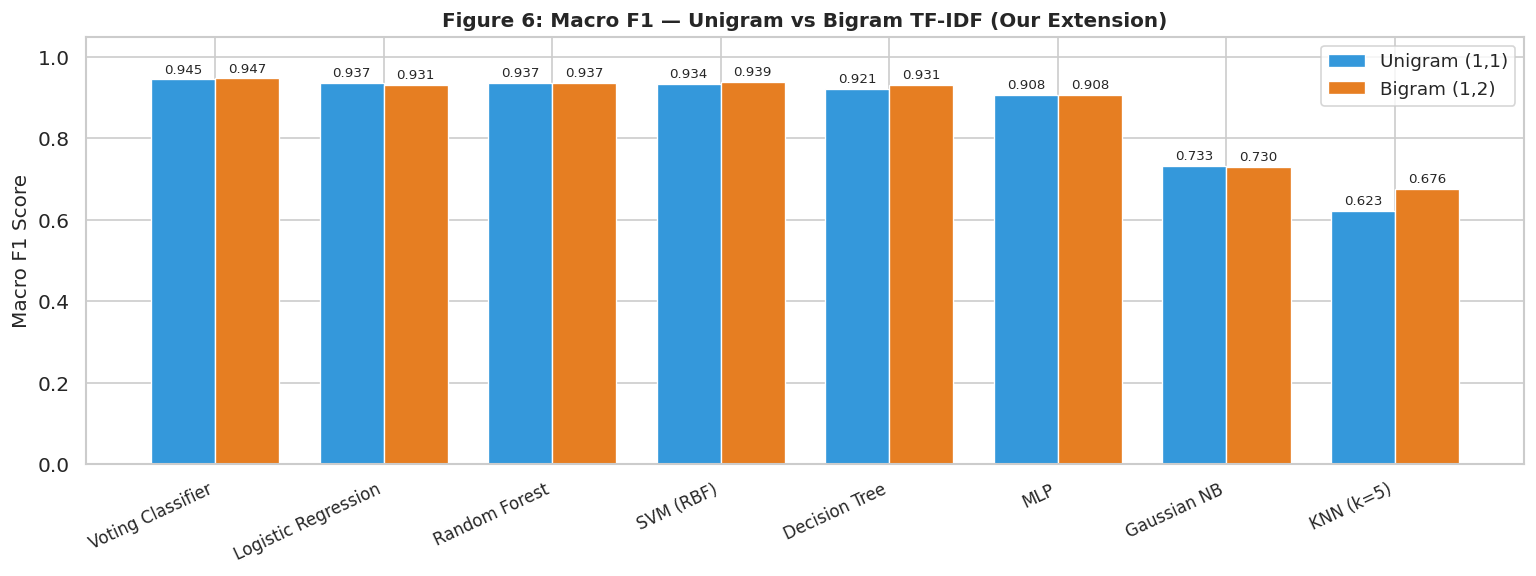

Saved: fig6_macro_f1_comparison.png


In [ ]:
#  10.1  Macro F1 Comparison: Unigram vs Bigram
uni_f1 = df_ext[df_ext['N-gram']=='Unigram (1,1)'][['Model','Macro F1']].rename(
    columns={'Macro F1':'Unigram'})
bi_f1  = df_ext[df_ext['N-gram']=='Bigram (1,2)'][['Model','Macro F1']].rename(
    columns={'Macro F1':'Bigram'})
compare_df = uni_f1.merge(bi_f1, on='Model').sort_values('Unigram', ascending=False)

x     = np.arange(len(compare_df))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, compare_df['Unigram'], width, label='Unigram (1,1)',
               color='#3498db', edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x + width/2, compare_df['Bigram'],  width, label='Bigram (1,2)',
               color='#e67e22', edgecolor='white', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(compare_df['Model'], rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Macro F1 Score', fontsize=12)
ax.set_title('Figure 6: Macro F1 — Unigram vs Bigram TF-IDF (Our Extension)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('fig6_macro_f1_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: fig6_macro_f1_comparison.png")

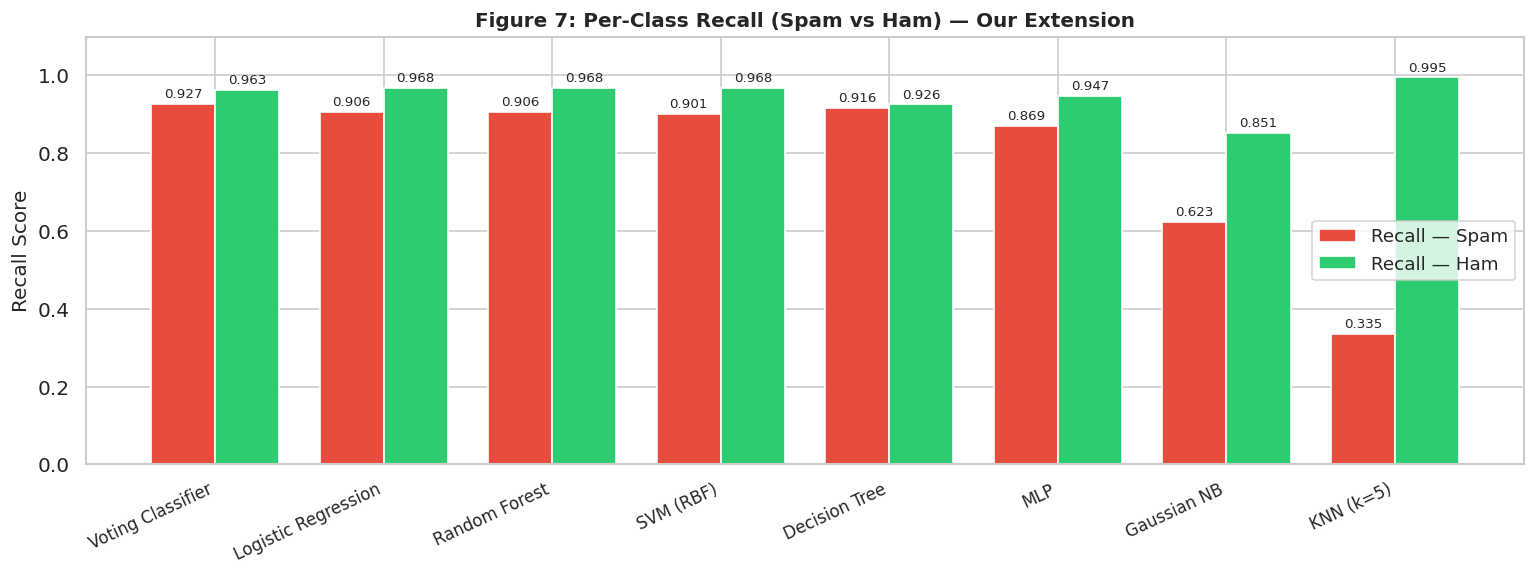

Saved: fig7_recall_breakdown.png


In [ ]:
#  10.2  Recall Breakdown: Spam vs Ham
uni_results = df_ext[df_ext['N-gram']=='Unigram (1,1)'].sort_values('Macro F1', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(len(uni_results))
width = 0.38

bars1 = ax.bar(x - width/2, uni_results['Recall (Spam)'], width, label='Recall — Spam',
               color='#e74c3c', edgecolor='white')
bars2 = ax.bar(x + width/2, uni_results['Recall (Ham)'],  width, label='Recall — Ham',
               color='#2ecc71', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(uni_results['Model'], rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Recall Score', fontsize=12)
ax.set_title('Figure 7: Per-Class Recall (Spam vs Ham) — Our Extension',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.10)
ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('fig7_recall_breakdown.png', bbox_inches='tight')
plt.show()
print("Saved: fig7_recall_breakdown.png")

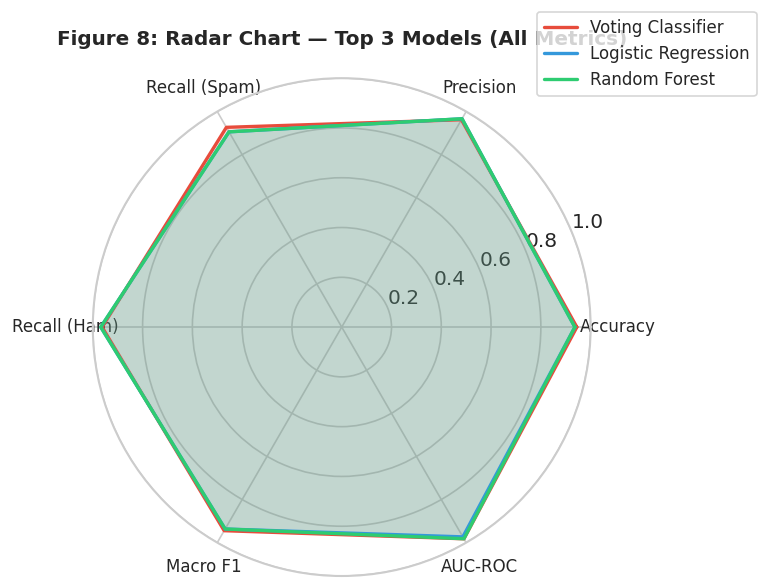

Saved: fig8_radar_chart.png


In [ ]:
#  10.3  Radar Chart — All Metrics for Best 3 Models
top3 = df_ext[df_ext['N-gram']=='Unigram (1,1)'].nlargest(3, 'Macro F1')

metrics_radar = ['Accuracy','Precision','Recall (Spam)','Recall (Ham)','Macro F1','AUC-ROC']
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the circle

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors_radar = ['#e74c3c', '#3498db', '#2ecc71']

for (_, row), color in zip(top3.iterrows(), colors_radar):
    values = [row[m] for m in metrics_radar]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=row['Model'])
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), metrics_radar, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Figure 8: Radar Chart — Top 3 Models (All Metrics)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.tight_layout()
plt.savefig('fig8_radar_chart.png', bbox_inches='tight')
plt.show()
print("Saved: fig8_radar_chart.png")

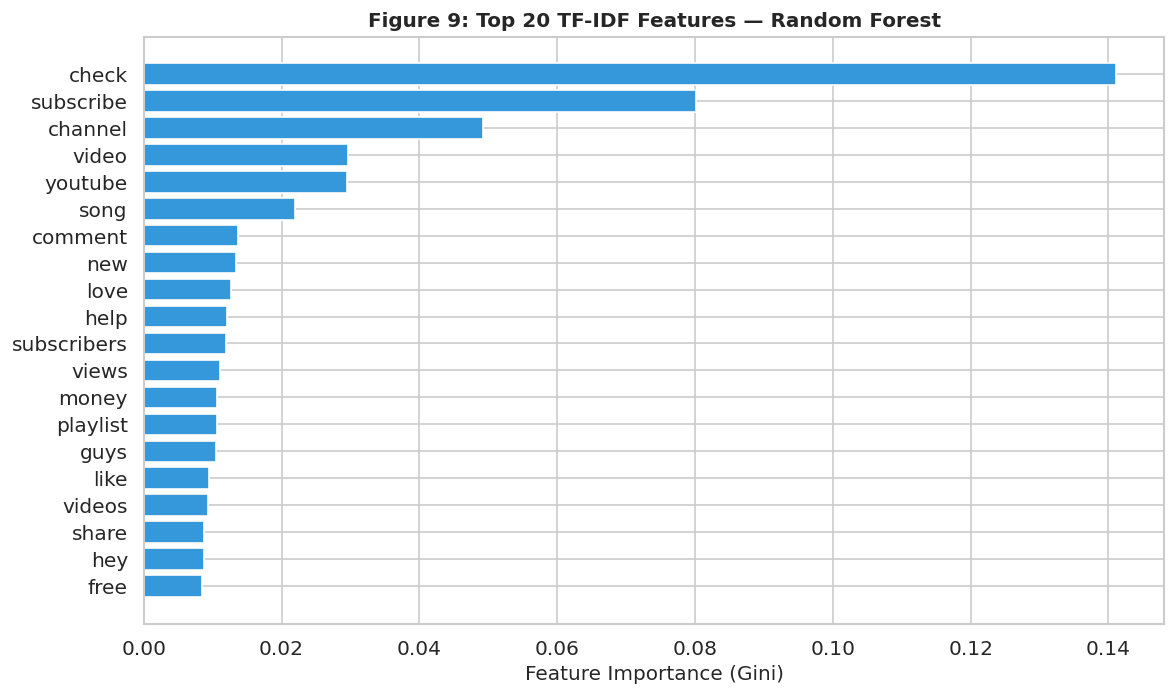

Saved: fig9_feature_importance.png


In [ ]:
#  10.4  TF-IDF Feature Importance for Best Model (Random Forest)
if 'Random Forest' in trained_models:
    rf = trained_models['Random Forest']
    importances  = rf.feature_importances_
    feature_names = tfidf_uni.get_feature_names_out()
    top20_idx    = importances.argsort()[-20:][::-1]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        [feature_names[i] for i in reversed(top20_idx)],
        [importances[i]   for i in reversed(top20_idx)],
        color='#3498db', edgecolor='white'
    )
    ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
    ax.set_title('Figure 9: Top 20 TF-IDF Features — Random Forest',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig9_feature_importance.png', bbox_inches='tight')
    plt.show()
    print("Saved: fig9_feature_importance.png")

---
## SECTION 11 — Final Results Summary Table

In [ ]:
# Master comparison table: Paper metrics vs Our extended metrics
paper_tbl = df_paper[['Model','Precision','AUC-ROC']].rename(
    columns={'Precision':'Paper Precision','AUC-ROC':'Paper AUC-ROC'})

our_tbl = df_ext[df_ext['N-gram']=='Unigram (1,1)'][[
    'Model','Accuracy','Macro F1','Recall (Spam)','Recall (Ham)','AUC-ROC'
]].rename(columns={'AUC-ROC':'Our AUC-ROC'})

master = paper_tbl.merge(our_tbl, on='Model')
master = master.sort_values('Our AUC-ROC', ascending=False).reset_index(drop=True)

float_cols = [c for c in master.columns if c != 'Model']
master_disp = master.copy()
master_disp[float_cols] = master_disp[float_cols].round(4)

print("═" * 100)
print("TABLE 3: MASTER RESULTS — Paper Metrics vs Our Extension (Unigram TF-IDF)")
print("═" * 100)
print(master_disp.to_string(index=False))
print("═" * 100)

print("\n KEY FINDINGS:")
best_uni = df_ext[df_ext['N-gram']=='Unigram (1,1)'].nlargest(1,'Macro F1').iloc[0]
best_bi  = df_ext[df_ext['N-gram']=='Bigram (1,2)'].nlargest(1,'Macro F1').iloc[0]
print(f"  Best model (Unigram) : {best_uni['Model']:20s}  Macro F1={best_uni['Macro F1']:.4f}")
print(f"  Best model (Bigram)  : {best_bi['Model']:20s}  Macro F1={best_bi['Macro F1']:.4f}")
diff = best_bi['Macro F1'] - best_uni['Macro F1']
print(f"  Bigram improvement   : {diff:+.4f}  ({'positive' if diff > 0 else 'negative or neutral'})")

════════════════════════════════════════════════════════════════════════════════════════════════════
TABLE 3: MASTER RESULTS — Paper Metrics vs Our Extension (Unigram TF-IDF)
════════════════════════════════════════════════════════════════════════════════════════════════════
              Model  Paper Precision  Paper AUC-ROC  Accuracy  Macro F1  Recall (Spam)  Recall (Ham)  Our AUC-ROC
  Voting Classifier           0.9620         0.9821    0.9446    0.9446         0.9267        0.9628       0.9821
      Random Forest           0.9665         0.9819    0.9367    0.9366         0.9058        0.9681       0.9819
Logistic Regression           0.9665         0.9732    0.9367    0.9366         0.9058        0.9681       0.9732
          SVM (RBF)           0.9663         0.9731    0.9340    0.9340         0.9005        0.9681       0.9731
                MLP           0.9432         0.9546    0.9077    0.9076         0.8691        0.9468       0.9546
      Decision Tree           0.9259    

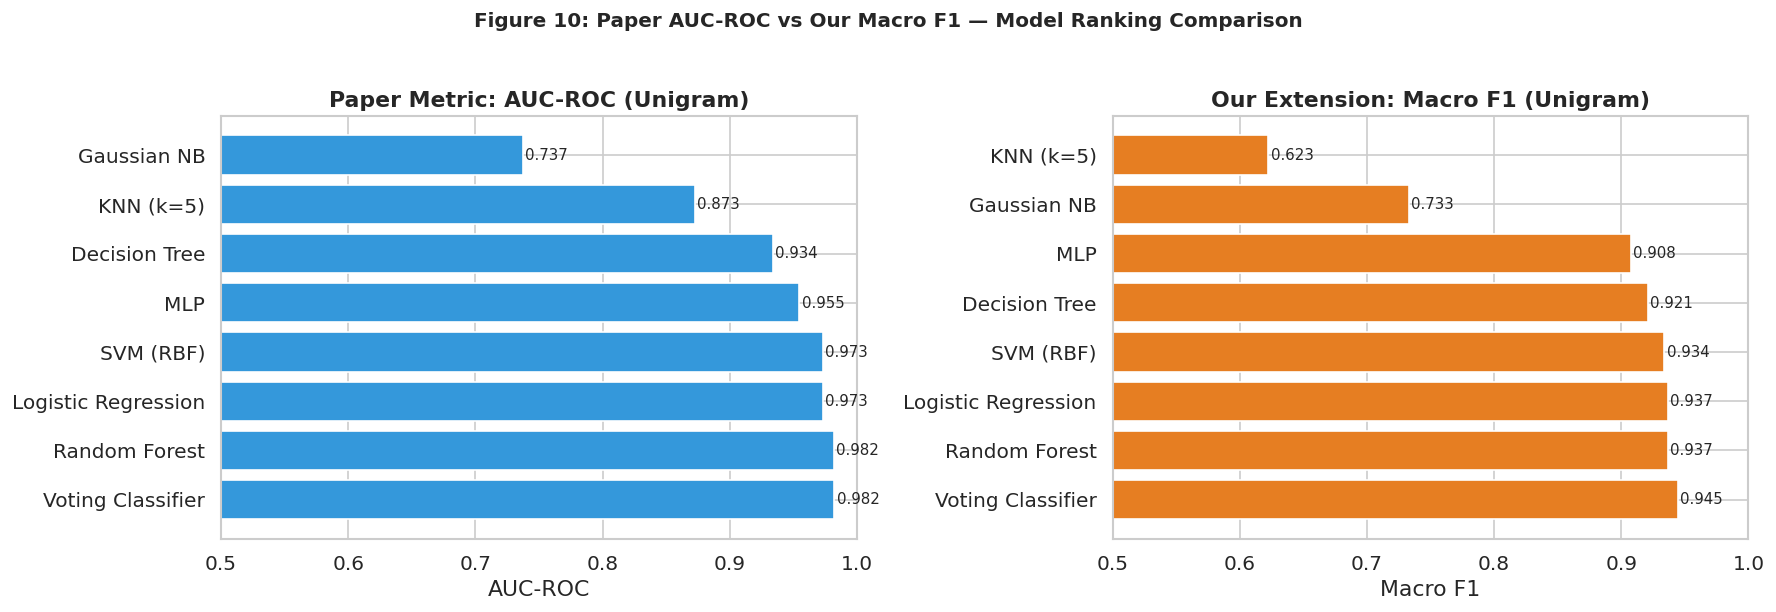

Saved: fig10_paper_vs_extension.png


In [ ]:
#  Final bar chart: paper AUC vs our Macro F1 side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sorted_m = master.sort_values('Paper AUC-ROC', ascending=False)

# Left: Paper AUC-ROC
axes[0].barh(sorted_m['Model'], sorted_m['Paper AUC-ROC'],
             color='#3498db', edgecolor='white')
axes[0].set_title('Paper Metric: AUC-ROC (Unigram)', fontweight='bold')
axes[0].set_xlabel('AUC-ROC')
axes[0].set_xlim(0.5, 1.0)
for i, val in enumerate(sorted_m['Paper AUC-ROC']):
    axes[0].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

# Right: Our Macro F1
sorted_m2 = master.sort_values('Macro F1', ascending=False)
axes[1].barh(sorted_m2['Model'], sorted_m2['Macro F1'],
             color='#e67e22', edgecolor='white')
axes[1].set_title('Our Extension: Macro F1 (Unigram)', fontweight='bold')
axes[1].set_xlabel('Macro F1')
axes[1].set_xlim(0.5, 1.0)
for i, val in enumerate(sorted_m2['Macro F1']):
    axes[1].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Figure 10: Paper AUC-ROC vs Our Macro F1 — Model Ranking Comparison',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig10_paper_vs_extension.png', bbox_inches='tight')
plt.show()
print("Saved: fig10_paper_vs_extension.png")

In [ ]:
#  Final file list
import glob
figures = sorted(glob.glob('fig*.png'))
print("═" * 45)
print("PROJECT COMPLETE — Output files generated:")
print("═" * 45)
for f in figures:
    size_kb = os.path.getsize(f) // 1024
    print(f"   {f:40s} {size_kb} KB")
print("\nTables generated:")
print("   Table 1 — Paper Replication Results")
print("   Table 2 — Our Extension (Macro F1 + Recall + Bigram)")
print("   Table 3 — Master Comparison (Paper vs Ours)")
print("\n All sections complete.")
print("   Cite: Xiao & Liang (2024) DOI 10.1016/j.mlwa.2024.100550")

═════════════════════════════════════════════
PROJECT COMPLETE — Output files generated:
═════════════════════════════════════════════
   fig10_paper_vs_extension.png             86 KB
   fig1_class_distribution.png              61 KB
   fig2_comment_length.png                  50 KB
   fig3_ngram_frequency.png                 153 KB
   fig4_roc_Decision_Tree.png               134 KB
   fig4_roc_Gaussian_NB.png                 146 KB
   fig4_roc_KNN_(k=5).png                   137 KB
   fig4_roc_Logistic_Regression.png         130 KB
   fig4_roc_MLP.png                         115 KB
   fig4_roc_Random_Forest.png               125 KB
   fig4_roc_SVM_(RBF).png                   121 KB
   fig4_roc_Voting_Classifier.png           127 KB
   fig4_roc_curves.png                      340 KB
   fig5_confusion_matrices.png              98 KB
   fig6_macro_f1_comparison.png             70 KB
   fig7_recall_breakdown.png                72 KB
   fig8_radar_chart.png                     106 KB
   f